In [ ]:
import pandas as pd
import numpy as np

In [ ]:
class PolynomialRegression:
    def transform(self,x):
        b = None
        for i in range(self.degree):
            b = np.stack((x,x**i) , axis = 1)
            a = b.shape
            b = np.reshape(b, newshape=(a[0],a[1]*a[2]))
        x = b
        return x
    def __init__(self,optimizer = "RMSprop",degree = 3):
        self.error = None
        self._y = None
        self.b = None
        self.w = None
        self.y = None
        self.x = None
        self.w_error = None
        self.b_error = None
        self.m_w = None
        self.m_b = None
        self.v_w = None
        self.v_b = None
        self.r_v_w = None
        self.r_v_b = None
        self.hat_m_w = None
        self.hat_m_b = None
        self.epoch_count = 1
        self.epoch_limit = None
        self.hat_v_w = None
        self.hat_v_b = None
        self.update_step = lambda: None
        self.metrics = self.Metrics(self)
        self.optimiser = optimizer
        self.degree = degree
    def fit(self,xs,ys,epochs = 100,):
        self.x = xs.copy()
        self.y = ys.copy()
        self.x = self.transform(self.x)
        self.w = np.zeros(self.x.shape[1])
        self.b = 0.0
        self.v_w = np.zeros(self.x.shape[1])
        self.m_w = np.zeros(self.x.shape[1])
        self.m_b = 0
        self.v_b = 0
        self._y = np.dot(self.x , self.w) + self.b
        self.error = np.mean((self._y - self.y)**2)
        self.b_error = 2*np.mean(self._y - self.y)
        self.w_error = 2*np.dot(self.x.transpose(),self._y - self.y)/self.x.shape[0]
        self.epoch_limit = epochs
        if self.optimiser == "adam":
            update_step = self.adam
        elif self.optimiser == "RMSprop":
            update_step = self.RMSprop
        elif self.optimiser == "momentum":
            update_step = self.momentum
        elif self.optimiser == "gd":
            update_step = self.gd
        else:
            raise ValueError(f"Unknown optimizer: {self.optimiser}")
        while self.epoch_count <= self.epoch_limit:
            update_step(gamma = 0.0005)
            self._y = np.dot(self.x,self.w) + self.b
            self.error = np.mean((self._y - self.y)**2)
            self.b_error = 2*np.mean(self._y - self.y)
            self.w_error = 2*np.dot(self.x.transpose(),self._y - self.y)/self.x.shape[0]
            self.epoch_count += 1
            print(f"Epochs {self.epoch_count -1} / {self.epoch_limit} | loss : {self.error}")
        self.metrics = self.Metrics(self)
    def adam(self, beta1 = 0.9 , beta2 = 0.999 ,epsilon = 10**-8,gamma = 0.001):
        #momentum variables
        self.m_w = beta1*self.m_w + (1 - beta1)*self.w_error
        self.m_b = beta1*self.m_b + (1 - beta1)*self.b_error
        #RMSpropFactors
        self.v_w = beta2*self.v_w + (1-beta2)*(self.w_error**2)
        self.v_b = beta2*self.v_b + (1-beta2)*(self.b_error**2)
        #bias correcting the variance values
        self.hat_v_w = self.v_w / (1 - beta2**self.epoch_count)
        self.hat_v_b = self.v_b / (1 - beta2**self.epoch_count)
        #RMSpropFactvectors for updating the final values
        self.r_v_w = 1 / (np.sqrt(self.hat_v_w + epsilon))
        self.r_v_b = 1 / (np.sqrt(self.hat_v_b + epsilon))
        #bias correcting the momentum values
        self.hat_m_w = self.m_w / (1 - beta1**self.epoch_count)
        self.hat_m_b = self.m_b / (1 - beta1**self.epoch_count)
        #Updating the final value
        self.b = self.b - self.hat_m_b*self.r_v_b*gamma
        self.w = self.w - np.multiply(self.hat_m_w,self.r_v_w)*gamma
    def RMSprop(self,beta2 = 0.999,epsilon = 10**-8, gamma = 0.001):
        self.v_w = beta2*self.v_w + (1-beta2)*(self.w_error**2)
        self.v_b = beta2*self.v_b + (1-beta2)*(self.b_error**2)
        self.r_v_w = 1 / (np.sqrt(self.v_w + epsilon))
        self.r_v_b = 1 / (np.sqrt(self.v_b + epsilon))
        self.b = self.b - self.b_error*self.r_v_b*gamma
        self.w = self.w - np.multiply(self.w_error,self.r_v_w)*gamma
    def momentum(self,beta1 = 0.9 , gamma = 0.001):
        self.m_w = beta1*self.m_w + (1 - beta1)*self.w_error
        self.m_b = beta1*self.m_b + (1 - beta1)*self.b_error
        self.b = self.b - self.m_b*gamma
        self.w = self.w - self.m_w*gamma
    def gd(self,gamma = 0.001):
        self.w = self.w - gamma*self.w_error
        self.b = self.b - self.b_error*gamma
    def predict(self,x):
        x = self.transform(x)
        out = np.dot(x , self.w) + self.b
        return out
    class Metrics:
        def __init__(self,outer):
            self.parameters = None
            self.outer = outer
            self.w = self.outer.w
            self.b = self.outer.b
        def params(self):
            self.parameters = np.append(self.w , [self.b], axis = None)
            return self.parameters
        def r2_score(self, x, y):
            y_pred = self.outer.predict(x)
            ss_res = np.sum((y - y_pred) ** 2)
            ss_tot = np.sum((y - np.mean(y)) ** 2)
            return 1 - (ss_res / ss_tot)
        def corr(self,x,y):
            y_pred = self.outer.predict(x)
            return np.corrcoef(y_pred,y)

In [ ]:
df = pd.read_csv('poly_train.csv')

In [ ]:
df.describe()


,x0,x1,x2,x3,x4,x5,x6,y
count,9.990000e+02,9.990000e+02,9.990000e+02,9.990000e+02,9.990000e+02,9.990000e+02,9.990000e+02,9.990000e+02
mean,-2.916141e-16,1.031318e-16,8.890675e-18,-1.778135e-17,3.165080e-16,3.556270e-18,3.556270e-18,-2.489389e-17
std,1.000501e+00,1.000501e+00,1.000501e+00,1.000501e+00,1.000501e+00,1.000501e+00,1.000501e+00,1.000501e+00
min,-1.699018e+00,-1.831649e+00,-1.795708e+00,-1.871546e+00,-1.757022e+00,-2.906268e+00,-2.769915e+00,-4.864986e-01
25%,-8.897394e-01,-8.670944e-01,-8.733400e-01,-8.730746e-01,-8.488988e-01,-6.930456e-01,-6.804023e-01,-4.864838e-01
50%,-2.831846e-02,-1.281502e-02,5.488697e-02,4.363933e-02,3.168394e-02,-5.342133e-03,-2.455947e-02,-4.780632e-01
75%,9.067487e-01,9.115318e-01,8.366839e-01,8.433667e-01,8.110455e-01,6.618755e-01,6.821138e-01,-5.682480e-02
max,1.810709e+00,1.717443e+00,1.890339e+00,1.864577e+00,1.771374e+00,3.000147e+00,2.969486e+00,4.345741e+00


In [ ]:
metric = pd.DataFrame({'label' : df.columns,
              'mean' : np.mean(df,axis =0),
              'std' : np.std(df,axis = 0)})

In [ ]:
metric

,label,mean,std
x0,x0,2.414945e+04,1.415144e+04
x1,x1,2.048001e+04,1.204220e+04
x2,x2,-1.105145e+02,1.089089e+02
x3,x3,-9.927589e+01,9.868302e+01
x4,x4,5.029562e+05,2.803286e+05
x5,x5,-2.649791e-02,9.436071e-01
x6,x6,-4.661943e-02,1.012199e+00
y,y,2.048959e+40,4.211645e+40


In [ ]:
for col in df.columns:
  df = df[df[col].isna() == False]

In [ ]:
for col in df.columns:
  df = df[np.abs((df[col] - np.mean(df[col]))/np.std(df[col])) < 3.0]

In [ ]:
for col in df.columns:
  df[col] = (df[col] - np.mean(df[col]))/np.std(df[col])

In [ ]:
model = PolynomialRegression(optimizer= 'gd' , degree = 5)
model.fit(df.drop('y',axis = 1).to_numpy() , df.y , epochs = 1000)

Epochs 1 / 1000 | loss : 0.9896831772719754
Epochs 2 / 1000 | loss : 0.9797229264785572
Epochs 3 / 1000 | loss : 0.9700940106858745
Epochs 4 / 1000 | loss : 0.9607738970993706
Epochs 5 / 1000 | loss : 0.9517424103297154
Epochs 6 / 1000 | loss : 0.9429814338715204
Epochs 7 / 1000 | loss : 0.9344746527696542
Epochs 8 / 1000 | loss : 0.9262073315046186
Epochs 9 / 1000 | loss : 0.9181661220225624
Epochs 10 / 1000 | loss : 0.9103388975924956
Epochs 11 / 1000 | loss : 0.9027146088144857
Epochs 12 / 1000 | loss : 0.8952831586461129
Epochs 13 / 1000 | loss : 0.8880352937753814
Epochs 14 / 1000 | loss : 0.8809625100594363
Epochs 15 / 1000 | loss : 0.8740569700805909
Epochs 16 / 1000 | loss : 0.8673114311534194
Epochs 17 / 1000 | loss : 0.8607191823566951
Epochs 18 / 1000 | loss : 0.8542739893682033
Epochs 19 / 1000 | loss : 0.8479700460544168
Epochs 20 / 1000 | loss : 0.8418019319152851
Epochs 21 / 1000 | loss : 0.8357645746108734
Epochs 22 / 1000 | loss : 0.8298532169045607
Epochs 23 / 1000 | 

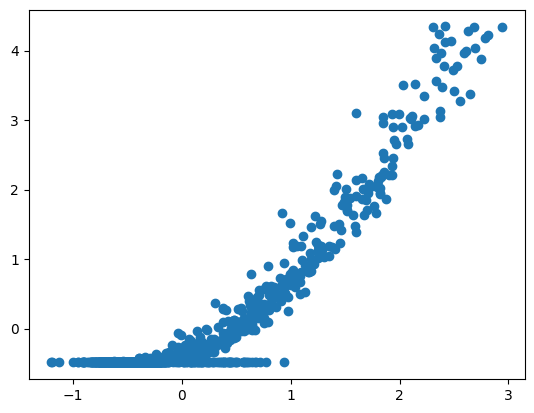

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(model.predict(df.drop('y' , axis = 1)),df.y)

In [ ]:
tdf = pd.read_csv('poly_test.csv')

In [ ]:
tdf.describe()

,x0,x1,x2,x3,x4,x5,x6
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,23632.685318,20080.281202,-113.638826,-102.615308,483911.197304,0.056713,-0.000055
std,14442.968267,12289.302309,108.380953,97.168139,287694.116552,1.009387,1.018097
min,261.908290,-180.745470,-302.114819,-285.418974,13943.679215,-3.887804,-3.444584
25%,10935.068058,8916.315430,-212.926172,-188.006478,225929.249063,-0.569714,-0.625047
50%,22455.437103,19011.758076,-111.367933,-102.300403,462079.882556,0.036904,0.017785
75%,36132.621299,30562.043798,-21.778446,-22.977799,739814.272092,0.778196,0.617868
max,49877.055487,44206.419101,81.246099,88.041572,995561.212543,2.629237,3.100647


In [ ]:
tdf.size

2800

In [ ]:
tdf.shape

(400, 7)

In [ ]:
for col in tdf.columns:
  a = metric.loc[metric.label == col]
  tdf[col] = (tdf[col] - np.float128(a.iloc[:,1].to_numpy()))/np.float128(a.iloc[:,2].to_numpy())

In [ ]:
pred = model.predict(tdf.to_numpy())*np.float128(metric.loc[metric.label == 'y'].iloc[:,2]) + np.float128(metric.loc[metric.label == 'y'].iloc[:,1])

In [ ]:
preddf = pd.DataFrame({'prediction' : pred},dtype= np.float128)

In [ ]:
preddf.isna().value_counts()

,count
prediction,
False,400


In [ ]:
preddf.to_csv('pred_poly.csv')